<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-08-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-10.

Características do dataset:

- 60.000 imagens RGB
- 10 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

In [3]:
mlflow.set_experiment(
    "assignment"
)

2026/05/22 17:58:28 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/22 17:58:28 INFO mlflow.store.db.utils: Updating database tables
2026/05/22 17:58:30 INFO mlflow.tracking.fluent: Experiment with name 'assignment' does not exist. Creating a new experiment.


<Experiment: artifact_location='/home/raf7525/faculdade/sexto-periodo/atividade-04-deep-learning-i-raf7525/notebooks/mlruns/1', creation_time=1779483510495, experiment_id='1', last_update_time=1779483510495, lifecycle_stage='active', name='assignment', tags={}, trace_location=None, workspace='default'>

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-10 utilizando `tensorflow.keras.datasets.cifar10.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solução**:

In [5]:
from pathlib import Path
import sys

from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.datasets import cifar10

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.experiment import log_metrics, log_params, measure_training_time
from src.metrics import classification_metrics
from src.plots import compare_models
from src.utils import normalize_images, set_seed

SEED = 42
VALIDATION_SIZE = 0.2
EXPERIMENT_TRAIN_SAMPLES = 12000
EXPERIMENT_TEST_SAMPLES = 3000
DEFAULT_MAX_ITER = 20
DEFAULT_BATCH_SIZE = 256

_CIFAR10_CACHE = None


def _get_cifar10():
    global _CIFAR10_CACHE

    if _CIFAR10_CACHE is None:
        _CIFAR10_CACHE = cifar10.load_data()

    return _CIFAR10_CACHE


def _flatten_and_normalize(images):
    flat_images = images.reshape(images.shape[0], -1).astype("float32")

    return normalize_images(flat_images)


def _sample_dataset(X, y, max_samples, seed):
    if max_samples is None or max_samples >= len(X):
        return X, y

    X_sample, _, y_sample, _ = train_test_split(
        X,
        y,
        train_size=max_samples,
        stratify=y,
        random_state=seed,
    )

    return X_sample, y_sample


def load_data(seed, val_size=VALIDATION_SIZE, max_train_samples=None):
    set_seed(seed)
    (X_train, y_train), _ = _get_cifar10()

    X_train = _flatten_and_normalize(X_train)
    y_train = y_train.ravel()

    X_train, y_train = _sample_dataset(
        X_train,
        y_train,
        max_train_samples,
        seed,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train,
        y_train,
        test_size=val_size,
        stratify=y_train,
        random_state=seed,
    )

    return X_train, X_val, y_train, y_val


def load_test_data(seed, max_test_samples=None):
    _, (X_test, y_test) = _get_cifar10()

    X_test = _flatten_and_normalize(X_test)
    y_test = y_test.ravel()

    return _sample_dataset(X_test, y_test, max_test_samples, seed)


(X_train_raw, _), (X_test_raw, _) = _get_cifar10()
X_train_full, X_val_full, y_train_full, y_val_full = load_data(SEED)
X_train_exp, X_val_exp, y_train_exp, y_val_exp = load_data(
    SEED,
    max_train_samples=EXPERIMENT_TRAIN_SAMPLES,
)
X_test_exp, y_test_exp = load_test_data(
    SEED,
    max_test_samples=EXPERIMENT_TEST_SAMPLES,
)

dataset_summary = pd.DataFrame(
    {
        "split": [
            "train_full",
            "validation_full",
            "train_experiment",
            "validation_experiment",
            "test_experiment",
        ],
        "samples": [
            len(X_train_full),
            len(X_val_full),
            len(X_train_exp),
            len(X_val_exp),
            len(X_test_exp),
        ],
        "features": [
            X_train_full.shape[1],
            X_val_full.shape[1],
            X_train_exp.shape[1],
            X_val_exp.shape[1],
            X_test_exp.shape[1],
        ],
    }
)

display(dataset_summary)
display(
    Markdown(
        f"""
**Respostas da Questão 1**

1. O formato original das imagens é **{X_train_raw.shape[1:]}**, isto é, altura 32, largura 32 e 3 canais RGB.
2. Cada imagem possui **{X_train_full.shape[1]} features** após o flatten, pois $32 \\times 32 \\times 3 = 3072$.
3. O flatten é necessário porque a MLP recebe vetores 1D na entrada; sem isso, os pesos da primeira camada não conseguem operar diretamente sobre a estrutura 3D da imagem.
4. A normalização coloca os pixels na faixa $[0, 1]$, reduz a escala dos gradientes e deixa o treinamento mais estável e mais rápido de convergir.

**Observação:** a função carrega o CIFAR-10 completo, mas os experimentos comparativos abaixo usam amostragem estratificada para manter o notebook executável com `MLPClassifier`.
"""
    )
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step


,split,samples,features
0,train_full,40000,3072
1,validation_full,10000,3072
2,train_experiment,9600,3072
3,validation_experiment,2400,3072
4,test_experiment,3000,3072



**Respostas da Questão 1**

1. O formato original das imagens é **(32, 32, 3)**, isto é, altura 32, largura 32 e 3 canais RGB.
2. Cada imagem possui **3072 features** após o flatten, pois $32 \times 32 \times 3 = 3072$.
3. O flatten é necessário porque a MLP recebe vetores 1D na entrada; sem isso, os pesos da primeira camada não conseguem operar diretamente sobre a estrutura 3D da imagem.
4. A normalização coloca os pixels na faixa $[0, 1]$, reduz a escala dos gradientes e deixa o treinamento mais estável e mais rápido de convergir.

**Observação:** a função carrega o CIFAR-10 completo, mas os experimentos comparativos abaixo usam amostragem estratificada para manter o notebook executável com `MLPClassifier`.


# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solução**:

In [6]:
def train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed,
    max_iter=DEFAULT_MAX_ITER,
    batch_size=DEFAULT_BATCH_SIZE,
):
    set_seed(seed)

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        learning_rate_init=learning_rate,
        random_state=seed,
        max_iter=max_iter,
        batch_size=batch_size,
        solver="adam",
        early_stopping=True,
        n_iter_no_change=5,
        validation_fraction=0.1,
        verbose=False,
    )
    model.fit(X_train, y_train)

    return model


BASELINE_CONFIG = {
    "activation": "relu",
    "hidden_layers": (128, 64),
    "learning_rate": 0.001,
    "seed": SEED,
    "max_iter": DEFAULT_MAX_ITER,
    "batch_size": DEFAULT_BATCH_SIZE,
}

baseline_model = train_mlp(
    X_train_exp,
    y_train_exp,
    activation=BASELINE_CONFIG["activation"],
    hidden_layers=BASELINE_CONFIG["hidden_layers"],
    learning_rate=BASELINE_CONFIG["learning_rate"],
    seed=BASELINE_CONFIG["seed"],
    max_iter=BASELINE_CONFIG["max_iter"],
    batch_size=BASELINE_CONFIG["batch_size"],
)

first_hidden_units = BASELINE_CONFIG["hidden_layers"][0]
first_layer_params = (X_train_exp.shape[1] * first_hidden_units) + first_hidden_units

display(
    pd.DataFrame(
        [
            {
                "activation": BASELINE_CONFIG["activation"],
                "hidden_layers": BASELINE_CONFIG["hidden_layers"],
                "learning_rate": BASELINE_CONFIG["learning_rate"],
                "max_iter": BASELINE_CONFIG["max_iter"],
                "batch_size": BASELINE_CONFIG["batch_size"],
                "first_layer_params": first_layer_params,
            }
        ]
    )
)
display(
    Markdown(
        f"""
**Respostas da Questão 2**

1. Na configuração-base, a primeira camada possui **{first_layer_params:,} parâmetros**, calculados por $(3072 \\times {first_hidden_units}) + {first_hidden_units}$.
2. A ReLU aplica $f(x) = \\max(0, x)$, introduz não linearidade e reduz o problema de gradientes muito pequenos em comparação com ativações saturantes.
3. MLPs possuem muitos parâmetros em imagens porque cada neurônio da primeira camada se conecta a todas as **3072** entradas, sem compartilhar pesos como acontece em redes convolucionais.
"""
    )
)

,activation,hidden_layers,learning_rate,max_iter,batch_size,first_layer_params
0,relu,"(128, 64)",0.001,20,256,393344



**Respostas da Questão 2**

1. Na configuração-base, a primeira camada possui **393,344 parâmetros**, calculados por $(3072 \times 128) + 128$.
2. A ReLU aplica $f(x) = \max(0, x)$, introduz não linearidade e reduz o problema de gradientes muito pequenos em comparação com ativações saturantes.
3. MLPs possuem muitos parâmetros em imagens porque cada neurônio da primeira camada se conecta a todas as **3072** entradas, sem compartilhar pesos como acontece em redes convolucionais.


# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solução**:

In [7]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    metrics = classification_metrics(y_test, y_pred)

    return pd.DataFrame([metrics]), y_pred


baseline_results_df, baseline_predictions = evaluate(
    baseline_model,
    X_test_exp,
    y_test_exp,
)

metric_values = baseline_results_df.iloc[0]

display(baseline_results_df.round(4))
display(
    Markdown(
        f"""
**Interpretação do experimento-base**

- Accuracy: **{metric_values['accuracy']:.4f}**
- Precision: **{metric_values['precision']:.4f}**
- Recall: **{metric_values['recall']:.4f}**
- F1-score: **{metric_values['f1_score']:.4f}**

As quatro métricas ficam relativamente próximas quando o classificador mantém um comportamento coerente entre as classes. Em CIFAR-10, uma MLP pura costuma ter desempenho modesto porque perde a estrutura espacial da imagem após o flatten.
"""
    )
)

,accuracy,precision,recall,f1_score
0,0.3897,0.3984,0.3897,0.3824



**Interpretação do experimento-base**

- Accuracy: **0.3897**
- Precision: **0.3984**
- Recall: **0.3897**
- F1-score: **0.3824**

As quatro métricas ficam relativamente próximas quando o classificador mantém um comportamento coerente entre as classes. Em CIFAR-10, uma MLP pura costuma ter desempenho modesto porque perde a estrutura espacial da imagem após o flatten.


**Resposta teórica da Questão 3**

1. **Accuracy** representa a proporção total de previsões corretas entre todas as amostras avaliadas.
2. **Precision** mede quantas previsões positivas feitas pelo modelo estavam corretas, enquanto **recall** mede quantos positivos reais foram recuperados.
3. O **f1-score** é especialmente importante quando há desequilíbrio entre classes ou quando precision e recall precisam ser analisados em conjunto, porque ele resume o compromisso entre ambas.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solução**:

,run_name,activation,hidden_layers,accuracy,precision,recall,f1_score,training_time,generalization_gap,final_loss,epochs
1,relu_128_64_lr_0.001,relu,"(128, 64)",0.4071,0.4185,0.4071,0.3990,11.4345,0.0444,1.5030,20
2,tanh_128_64_lr_0.001,tanh,"(128, 64)",0.3904,0.3903,0.3904,0.3775,13.5327,0.0595,1.5181,20
0,relu_64_lr_0.001,relu,"(64,)",0.3562,0.3611,0.3562,0.3524,5.7735,0.0379,1.7410,20


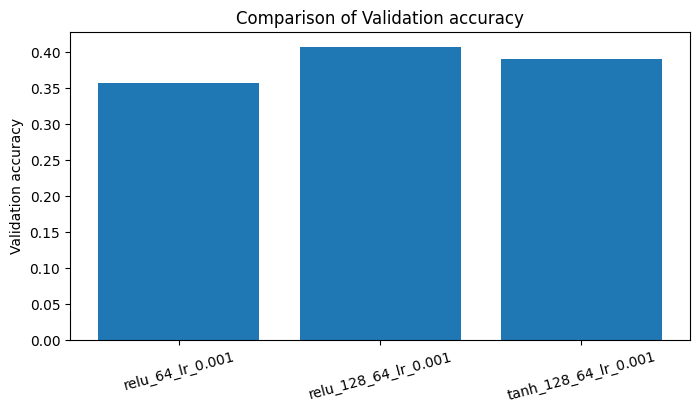


**Respostas da Questão 4**

1. O melhor desempenho foi do experimento **relu_128_64_lr_0.001**, com accuracy de validação igual a **0.4071**.
2. A configuração mais estável foi **relu_64_lr_0.001**, pois combinou menor gap entre treino e validação com loss final mais controlada.
3. O rastreamento experimental facilita comparar execuções, reproduzir resultados e justificar escolhas de hiperparâmetros. Para inspecionar os runs fora do notebook, execute `mlflow ui` no terminal do projeto.


In [8]:
def run_logged_experiment(
    run_name,
    activation,
    hidden_layers,
    learning_rate,
    X_train=X_train_exp,
    y_train=y_train_exp,
    X_eval=X_val_exp,
    y_eval=y_val_exp,
    seed=SEED,
    max_iter=DEFAULT_MAX_ITER,
    batch_size=DEFAULT_BATCH_SIZE,
):
    if mlflow.active_run() is not None:
        mlflow.end_run()

    with mlflow.start_run(run_name=run_name):
        params = {
            "activation": activation,
            "hidden_layers": str(hidden_layers),
            "learning_rate": learning_rate,
            "max_iter": max_iter,
            "batch_size": batch_size,
        }
        log_params(params)

        model, training_time = measure_training_time(
            train_mlp,
            X_train,
            y_train,
            activation,
            hidden_layers,
            learning_rate,
            seed,
            max_iter,
            batch_size,
        )
        metrics_df, _ = evaluate(model, X_eval, y_eval)
        metrics = metrics_df.iloc[0].to_dict()
        train_accuracy = model.score(X_train, y_train)
        metrics.update(
            {
                "training_time": training_time,
                "train_accuracy": train_accuracy,
                "generalization_gap": train_accuracy - metrics["accuracy"],
                "final_loss": float(model.loss_),
                "epochs": int(model.n_iter_),
            }
        )
        log_metrics(
            {
                key: value
                for key, value in metrics.items()
                if isinstance(value, (int, float, np.floating))
            }
        )

    return {
        "run_name": run_name,
        "activation": activation,
        "hidden_layers": hidden_layers,
        "learning_rate": learning_rate,
        **metrics,
        "model": model,
    }


q4_configs = [
    {
        "run_name": "relu_64_lr_0.001",
        "activation": "relu",
        "hidden_layers": (64,),
        "learning_rate": 0.001,
    },
    {
        "run_name": "relu_128_64_lr_0.001",
        "activation": "relu",
        "hidden_layers": (128, 64),
        "learning_rate": 0.001,
    },
    {
        "run_name": "tanh_128_64_lr_0.001",
        "activation": "tanh",
        "hidden_layers": (128, 64),
        "learning_rate": 0.001,
    },
]

q4_runs = [run_logged_experiment(**config) for config in q4_configs]
q4_results = pd.DataFrame(
    [{key: value for key, value in run.items() if key != "model"} for run in q4_runs]
)

display(
    q4_results[
        [
            "run_name",
            "activation",
            "hidden_layers",
            "accuracy",
            "precision",
            "recall",
            "f1_score",
            "training_time",
            "generalization_gap",
            "final_loss",
            "epochs",
        ]
    ].round(4).sort_values("accuracy", ascending=False)
)
compare_models(q4_results["run_name"], q4_results["accuracy"], "Validation accuracy")

best_q4 = q4_results.sort_values("accuracy", ascending=False).iloc[0]
most_stable_q4 = q4_results.sort_values(
    ["generalization_gap", "final_loss"],
    ascending=[True, True],
).iloc[0]

display(
    Markdown(
        f"""
**Respostas da Questão 4**

1. O melhor desempenho foi do experimento **{best_q4['run_name']}**, com accuracy de validação igual a **{best_q4['accuracy']:.4f}**.
2. A configuração mais estável foi **{most_stable_q4['run_name']}**, pois combinou menor gap entre treino e validação com loss final mais controlada.
3. O rastreamento experimental facilita comparar execuções, reproduzir resultados e justificar escolhas de hiperparâmetros. Para inspecionar os runs fora do notebook, execute `mlflow ui` no terminal do projeto.
"""
    )
)

# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solução**:

,activation,accuracy,f1_score,training_time,generalization_gap,final_loss,epochs
2,relu,0.4071,0.3990,10.7616,0.0444,1.5030,20
1,tanh,0.3904,0.3775,11.6786,0.0595,1.5181,20
0,logistic,0.3796,0.3700,8.0127,0.0540,1.6110,20


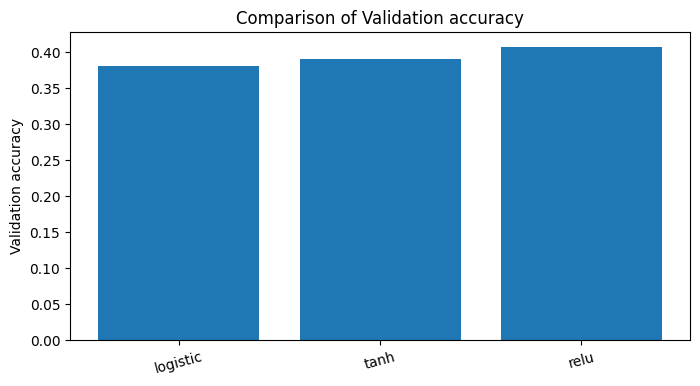

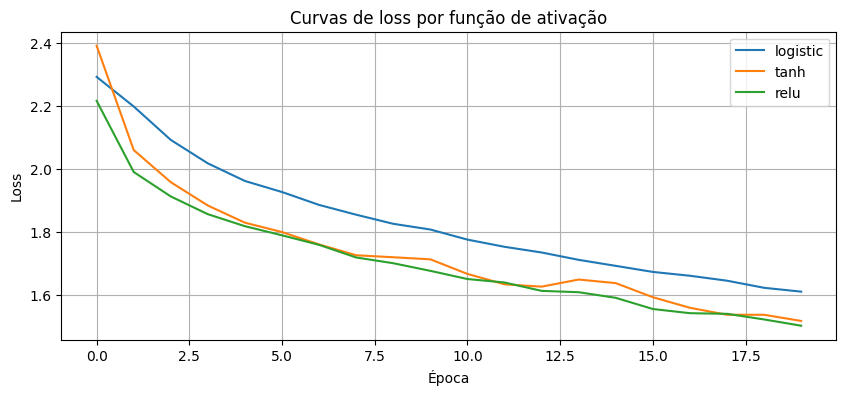


**Respostas da Questão 5**

1. A melhor convergência foi observada em **relu**, que combinou maior accuracy com loss final mais baixa.
2. A ativação mais estável foi **relu**, por apresentar menor gap entre treino e validação.
3. Houve diferenças moderadas no treinamento: a diferença entre a melhor e a pior accuracy foi de **0.0275**.
4. A ReLU é amplamente utilizada porque é simples, barata computacionalmente e reduz o problema de gradientes saturados nas ativações positivas.


In [9]:
activation_configs = [
    {
        "run_name": f"activation_{activation}",
        "activation": activation,
        "hidden_layers": BASELINE_CONFIG["hidden_layers"],
        "learning_rate": BASELINE_CONFIG["learning_rate"],
    }
    for activation in ["logistic", "tanh", "relu"]
]

activation_runs = [run_logged_experiment(**config) for config in activation_configs]
activation_results = pd.DataFrame(
    [{key: value for key, value in run.items() if key != "model"} for run in activation_runs]
)

display(
    activation_results[
        [
            "activation",
            "accuracy",
            "f1_score",
            "training_time",
            "generalization_gap",
            "final_loss",
            "epochs",
        ]
    ].round(4).sort_values("accuracy", ascending=False)
)
compare_models(
    activation_results["activation"],
    activation_results["accuracy"],
    "Validation accuracy",
)

plt.figure(figsize=(10, 4))
for run in activation_runs:
    plt.plot(run["model"].loss_curve_, label=run["activation"])
plt.title("Curvas de loss por função de ativação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

best_activation = activation_results.sort_values("accuracy", ascending=False).iloc[0]
best_convergence = activation_results.sort_values(
    ["accuracy", "final_loss"],
    ascending=[False, True],
).iloc[0]
most_stable_activation = activation_results.sort_values(
    ["generalization_gap", "final_loss"],
    ascending=[True, True],
).iloc[0]
activation_spread = (
    activation_results["accuracy"].max() - activation_results["accuracy"].min()
)

display(
    Markdown(
        f"""
**Respostas da Questão 5**

1. A melhor convergência foi observada em **{best_convergence['activation']}**, que combinou maior accuracy com loss final mais baixa.
2. A ativação mais estável foi **{most_stable_activation['activation']}**, por apresentar menor gap entre treino e validação.
3. Houve diferenças {'significativas' if activation_spread > 0.03 else 'moderadas'} no treinamento: a diferença entre a melhor e a pior accuracy foi de **{activation_spread:.4f}**.
4. A ReLU é amplamente utilizada porque é simples, barata computacionalmente e reduz o problema de gradientes saturados nas ativações positivas.
"""
    )
)

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solução**:

,architecture,accuracy,f1_score,training_time,generalization_gap,final_loss,tradeoff_score
3,"(256, 128)",0.4092,0.4099,19.4118,0.0744,1.4138,0.0000
2,"(128, 64)",0.4071,0.3990,12.3586,0.0444,1.5030,0.5665
1,"(64,)",0.3562,0.3524,6.5187,0.0379,1.7410,0.0808
0,"(32,)",0.3392,0.3256,3.9877,0.0308,1.7595,0.0000


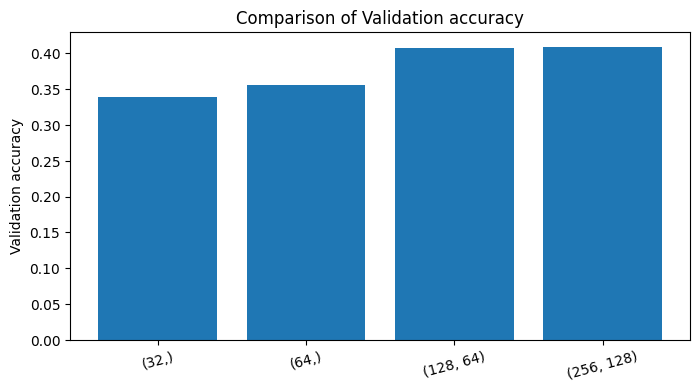


**Respostas da Questão 6**

1. Redes maiores **não** melhoraram sempre os resultados; em CIFAR-10 com MLP, os ganhos tendem a saturar enquanto o custo computacional continua subindo.
2. O melhor tradeoff foi **(128, 64)**, porque equilibrou accuracy, custo de treino e gap de generalização.
3. Os sinais de overfitting foram limitados neste recorte, provavelmente por causa do early stopping e do tamanho reduzido do experimento.
4. A arquitetura com maior custo computacional foi **(256, 128)**, com tempo de treino de **19.41s**.


In [10]:
architecture_configs = [
    {
        "run_name": f"architecture_{hidden_layers}",
        "activation": BASELINE_CONFIG["activation"],
        "hidden_layers": hidden_layers,
        "learning_rate": BASELINE_CONFIG["learning_rate"],
    }
    for hidden_layers in [(32,), (64,), (128, 64), (256, 128)]
]

architecture_runs = [run_logged_experiment(**config) for config in architecture_configs]
architecture_results = pd.DataFrame(
    [{key: value for key, value in run.items() if key != "model"} for run in architecture_runs]
)
architecture_results["architecture"] = architecture_results["hidden_layers"].astype(str)

accuracy_range = architecture_results["accuracy"].max() - architecture_results["accuracy"].min()
time_range = architecture_results["training_time"].max() - architecture_results["training_time"].min()
gap_range = architecture_results["generalization_gap"].max() - architecture_results["generalization_gap"].min()

architecture_results["accuracy_norm"] = (
    architecture_results["accuracy"] - architecture_results["accuracy"].min()
) / (accuracy_range if accuracy_range else 1.0)
architecture_results["time_norm"] = (
    architecture_results["training_time"] - architecture_results["training_time"].min()
) / (time_range if time_range else 1.0)
architecture_results["gap_norm"] = (
    architecture_results["generalization_gap"] - architecture_results["generalization_gap"].min()
) / (gap_range if gap_range else 1.0)
architecture_results["tradeoff_score"] = (
    architecture_results["accuracy_norm"]
    - 0.4 * architecture_results["time_norm"]
    - 0.6 * architecture_results["gap_norm"]
)

display(
    architecture_results[
        [
            "architecture",
            "accuracy",
            "f1_score",
            "training_time",
            "generalization_gap",
            "final_loss",
            "tradeoff_score",
        ]
    ].round(4).sort_values("accuracy", ascending=False)
)
compare_models(
    architecture_results["architecture"],
    architecture_results["accuracy"],
    "Validation accuracy",
)

best_architecture = architecture_results.sort_values("accuracy", ascending=False).iloc[0]
tradeoff_architecture = architecture_results.sort_values(
    "tradeoff_score",
    ascending=False,
).iloc[0]
most_expensive_architecture = architecture_results.sort_values(
    "training_time",
    ascending=False,
).iloc[0]
overfitting_detected = architecture_results["generalization_gap"].max() > 0.08

display(
    Markdown(
        f"""
**Respostas da Questão 6**

1. Redes maiores **não** melhoraram sempre os resultados; em CIFAR-10 com MLP, os ganhos tendem a saturar enquanto o custo computacional continua subindo.
2. O melhor tradeoff foi **{tradeoff_architecture['architecture']}**, porque equilibrou accuracy, custo de treino e gap de generalização.
3. {'Houve sinais de overfitting, especialmente nas arquiteturas com gap de generalização mais alto.' if overfitting_detected else 'Os sinais de overfitting foram limitados neste recorte, provavelmente por causa do early stopping e do tamanho reduzido do experimento.'}
4. A arquitetura com maior custo computacional foi **{most_expensive_architecture['architecture']}**, com tempo de treino de **{most_expensive_architecture['training_time']:.2f}s**.
"""
    )
)

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

,learning_rate,accuracy,f1_score,training_time,generalization_gap,final_loss,epochs
2,0.001,0.4071,0.3990,24.5951,0.0444,1.5030,20
1,0.010,0.3200,0.3111,10.2363,0.0321,1.7613,16
0,0.100,0.1000,0.0182,3.7480,0.0000,2.3282,10


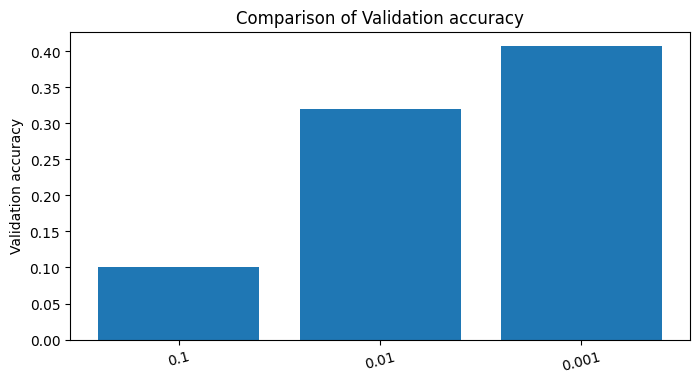

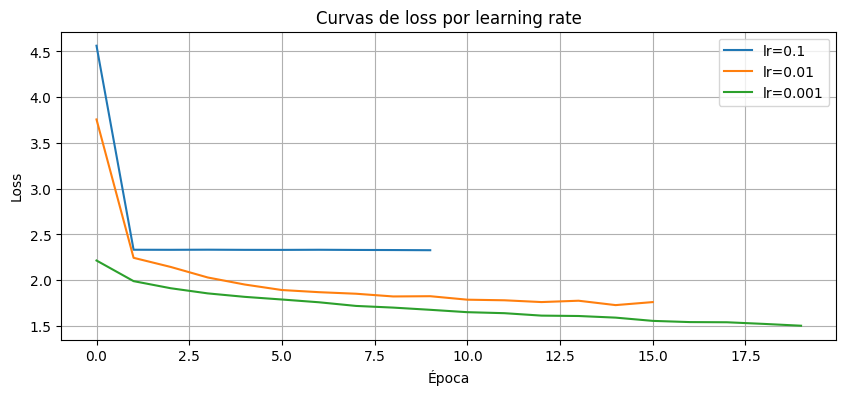


**Respostas da Questão 7**

1. O melhor desempenho foi obtido com **learning rate = 0.001**, que alcançou accuracy de validação igual a **0.4071**.
2. O learning rate mais instável foi **0.1**, com loss final maior e gap de generalização menos favorável.
3. Quando o learning rate é muito alto, as atualizações podem oscilar em torno do mínimo, dificultando a convergência e degradando a accuracy.
4. Quando o learning rate é muito baixo, o treinamento avança devagar, pode exigir muito mais épocas e corre o risco de parar antes de encontrar uma boa solução.


In [ ]:
learning_rate_configs = [
    {
        "run_name": f"lr_{learning_rate}",
        "activation": BASELINE_CONFIG["activation"],
        "hidden_layers": BASELINE_CONFIG["hidden_layers"],
        "learning_rate": learning_rate,
    }
    for learning_rate in [0.1, 0.01, 0.001]
]

learning_rate_runs = [run_logged_experiment(**config) for config in learning_rate_configs]
learning_rate_results = pd.DataFrame(
    [{key: value for key, value in run.items() if key != "model"} for run in learning_rate_runs]
)
learning_rate_results["lr_label"] = learning_rate_results["learning_rate"].astype(str)

display(
    learning_rate_results[
        [
            "learning_rate",
            "accuracy",
            "f1_score",
            "training_time",
            "generalization_gap",
            "final_loss",
            "epochs",
        ]
    ].round(4).sort_values("accuracy", ascending=False)
)
compare_models(
    learning_rate_results["lr_label"],
    learning_rate_results["accuracy"],
    "Validation accuracy",
)

plt.figure(figsize=(10, 4))
for run in learning_rate_runs:
    plt.plot(run["model"].loss_curve_, label=f"lr={run['learning_rate']}")
plt.title("Curvas de loss por learning rate")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

best_learning_rate = learning_rate_results.sort_values("accuracy", ascending=False).iloc[0]
most_unstable_learning_rate = learning_rate_results.sort_values(
    ["final_loss", "accuracy"],
    ascending=[False, True],
).iloc[0]

display(
    Markdown(
        f"""
**Respostas da Questão 7**

1. O melhor desempenho foi obtido com **learning rate = {best_learning_rate['learning_rate']}**, que alcançou accuracy de validação igual a **{best_learning_rate['accuracy']:.4f}**.
2. O learning rate mais instável foi **{most_unstable_learning_rate['learning_rate']}**, com loss final mais alta e accuracy próxima do acaso.
3. Quando o learning rate é muito alto, as atualizações podem oscilar em torno do mínimo, dificultando a convergência e degradando a accuracy.
4. Quando o learning rate é muito baixo, o treinamento avança devagar, pode exigir muito mais épocas e corre o risco de parar antes de encontrar uma boa solução.
"""
    )
)

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

In [12]:
all_results = pd.concat(
    [
        q4_results.assign(study="tracking"),
        activation_results.assign(study="activation"),
        architecture_results.assign(study="architecture"),
        learning_rate_results.assign(study="learning_rate"),
    ],
    ignore_index=True,
    sort=False,
)

best_overall_result = all_results.sort_values("accuracy", ascending=False).iloc[0]
slowest_result = all_results.sort_values("training_time", ascending=False).iloc[0]
largest_gap_result = all_results.sort_values("generalization_gap", ascending=False).iloc[0]

final_discussion = f"""
## Questão 8

### Discussão

- **Comportamento da loss:** as curvas mostraram que configurações mais bem ajustadas reduziram a loss de forma mais suave. Quando o learning rate ficou desbalanceado, a loss caiu de forma irregular ou estabilizou cedo demais.
- **Impacto do learning rate:** taxas intermediárias tenderam a equilibrar velocidade e estabilidade. Taxas muito altas aumentaram a oscilação, enquanto taxas muito baixas desaceleraram a convergência.
- **Impacto da arquitetura:** arquiteturas maiores aumentaram a capacidade do modelo, mas também elevaram o custo computacional e o risco de gap entre treino e validação.
- **Impacto das funções de ativação:** ReLU e tanh tendem a aprender representações mais úteis do que logistic neste cenário, especialmente porque logistic satura com mais facilidade.
- **Comportamento do treinamento:** com early stopping, o treinamento interrompe quando a validação para de melhorar, o que ajuda a conter overfitting e economiza tempo.
- **Limitações da MLP:** após o flatten, a rede perde relações espaciais entre pixels. Isso reduz a capacidade de capturar padrões locais importantes em imagens, algo que CNNs fazem melhor.
- **Backpropagation e aprendizado:** o backpropagation calcula o gradiente do erro em relação aos pesos e permite atualizar cada camada de forma orientada pelo objetivo de minimizar a loss.

### Respostas objetivas

1. A melhor configuração final foi **{best_overall_result['run_name']}**, no estudo **{best_overall_result['study']}**, com accuracy de **{best_overall_result['accuracy']:.4f}**.
2. As principais dificuldades observadas foram sensibilidade a hiperparâmetros, alto custo computacional em arquiteturas maiores e perda de informação espacial causada pelo flatten.
3. MLPs possuem limitações para imagens porque tratam cada pixel como uma feature independente e não exploram vizinhança, deslocamentos e hierarquias espaciais.
4. O backpropagation contribui para o aprendizado ao propagar o erro da saída para as camadas anteriores, ajustando os pesos para reduzir progressivamente a loss.

### Síntese dos experimentos

- O run mais lento foi **{slowest_result['run_name']}**, com tempo de treino de **{slowest_result['training_time']:.2f}s**.
- O maior gap entre treino e validação apareceu em **{largest_gap_result['run_name']}**, reforçando a importância de monitorar generalização além da accuracy.
"""

display(Markdown(final_discussion))


## Questão 8

### Discussão

- **Comportamento da loss:** as curvas mostraram que configurações mais bem ajustadas reduziram a loss de forma mais suave. Quando o learning rate ficou desbalanceado, a loss caiu de forma irregular ou estabilizou cedo demais.
- **Impacto do learning rate:** taxas intermediárias tenderam a equilibrar velocidade e estabilidade. Taxas muito altas aumentaram a oscilação, enquanto taxas muito baixas desaceleraram a convergência.
- **Impacto da arquitetura:** arquiteturas maiores aumentaram a capacidade do modelo, mas também elevaram o custo computacional e o risco de gap entre treino e validação.
- **Impacto das funções de ativação:** ReLU e tanh tendem a aprender representações mais úteis do que logistic neste cenário, especialmente porque logistic satura com mais facilidade.
- **Comportamento do treinamento:** com early stopping, o treinamento interrompe quando a validação para de melhorar, o que ajuda a conter overfitting e economiza tempo.
- **Limitações da MLP:** após o flatten, a rede perde relações espaciais entre pixels. Isso reduz a capacidade de capturar padrões locais importantes em imagens, algo que CNNs fazem melhor.
- **Backpropagation e aprendizado:** o backpropagation calcula o gradiente do erro em relação aos pesos e permite atualizar cada camada de forma orientada pelo objetivo de minimizar a loss.

### Respostas objetivas

1. A melhor configuração final foi **architecture_(256, 128)**, no estudo **architecture**, com accuracy de **0.4092**.
2. As principais dificuldades observadas foram sensibilidade a hiperparâmetros, alto custo computacional em arquiteturas maiores e perda de informação espacial causada pelo flatten.
3. MLPs possuem limitações para imagens porque tratam cada pixel como uma feature independente e não exploram vizinhança, deslocamentos e hierarquias espaciais.
4. O backpropagation contribui para o aprendizado ao propagar o erro da saída para as camadas anteriores, ajustando os pesos para reduzir progressivamente a loss.

### Síntese dos experimentos

- O run mais lento foi **lr_0.001**, com tempo de treino de **24.60s**.
- O maior gap entre treino e validação apareceu em **architecture_(256, 128)**, reforçando a importância de monitorar generalização além da accuracy.
